#  CNN Notebook

Classes: `crack`, `manhole`, `pothole`.

What this notebook covers:
- Dataset loading
- EDA
- Class imbalance analysis
- Image visualization
- CNN architecture with Conv2D, BatchNorm, Dropout, L2 regularization
- Training callbacks
- Evaluation using sklearn metrics
- Confusion matrix
- Precision, recall, F1-score, AUC
- Sample predictions

## 1. Set Project Path

In [1]:
import os

PROJECT_DIR = r"C:\Users\skjha\Documents\Codex\2026-06-01\2-road-damage-detection-for-smart"
os.chdir(PROJECT_DIR)
print("Current directory:", os.getcwd())

Current directory: C:\Users\skjha\Documents\Codex\2026-06-01\2-road-damage-detection-for-smart


## 2. Import Required Libraries

In [2]:
from pathlib import Path
import json
import random
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPU devices: []


## 3. Basic Configuration

In [3]:
DATA_DIR = Path("data/processed")
MODEL_DIR = Path("ml/models")
REPORT_DIR = Path("ml/reports")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
LEARNING_RATE = 1e-3
DROPOUT_RATE = 0.40
EPOCHS = 30

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 4. EDA: Create Metadata Table

In [4]:
def build_metadata(data_dir):
    rows = []
    for split in ["train", "val", "test"]:
        split_dir = data_dir / split
        for class_dir in sorted(split_dir.iterdir()):
            if not class_dir.is_dir():
                continue
            for image_path in class_dir.glob("*.jpg"):
                image = cv2.imread(str(image_path))
                if image is None:
                    continue
                height, width = image.shape[:2]
                rows.append({
                    "split": split,
                    "class_name": class_dir.name,
                    "path": str(image_path),
                    "width": width,
                    "height": height,
                    "aspect_ratio": width / height,
                })
    return pd.DataFrame(rows)

metadata_df = build_metadata(DATA_DIR)
metadata_df.head()

,split,class_name,path,width,height,aspect_ratio
0,train,crack,data\processed\train\crack\20250216_164325_005...,61,49,1.244898
1,train,crack,data\processed\train\crack\20250216_164325_006...,40,40,1.000000
2,train,crack,data\processed\train\crack\20250216_164325_011...,49,57,0.859649
3,train,crack,data\processed\train\crack\20250216_164325_012...,169,86,1.965116
4,train,crack,data\processed\train\crack\20250216_164521_000...,46,49,0.938776


In [5]:
metadata_df.groupby(["split", "class_name"]).size().unstack(fill_value=0)

class_name,crack,manhole,pothole
split,,,
test,347,69,94
train,1579,301,442
val,341,73,82


## 5. Visualize Class Distribution

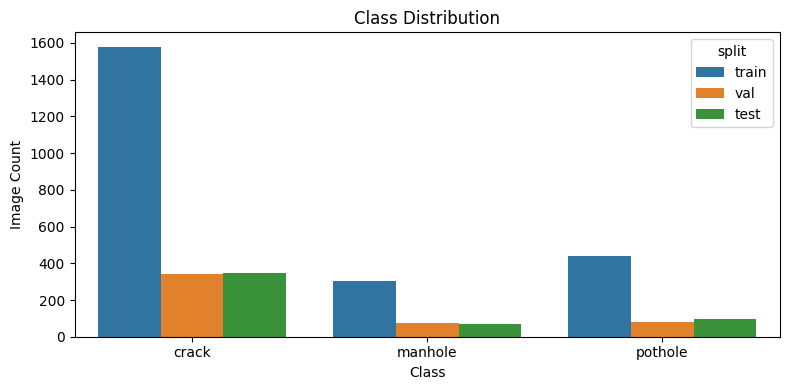

In [6]:
plt.figure(figsize=(8, 4))
sns.countplot(data=metadata_df, x="class_name", hue="split")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

## 6. Visualize Image Size Distribution

,width,height,aspect_ratio
count,3328.000000,3328.000000,3328.000000
mean,121.992188,60.591046,2.192785
std,89.481070,40.560235,1.134696
min,25.000000,26.000000,0.207407
25%,70.000000,35.000000,1.443333
50%,97.000000,47.000000,2.000000
75%,143.000000,74.000000,2.750000
max,640.000000,360.000000,15.096774


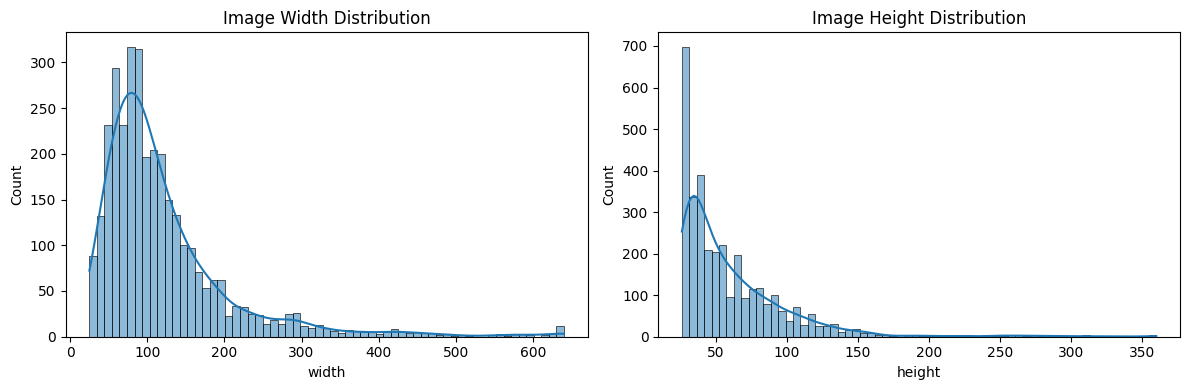

In [7]:
display(metadata_df[["width", "height", "aspect_ratio"]].describe())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(metadata_df["width"], kde=True)
plt.title("Image Width Distribution")

plt.subplot(1, 2, 2)
sns.histplot(metadata_df["height"], kde=True)
plt.title("Image Height Distribution")

plt.tight_layout()
plt.show()

## 7. Show Sample Images

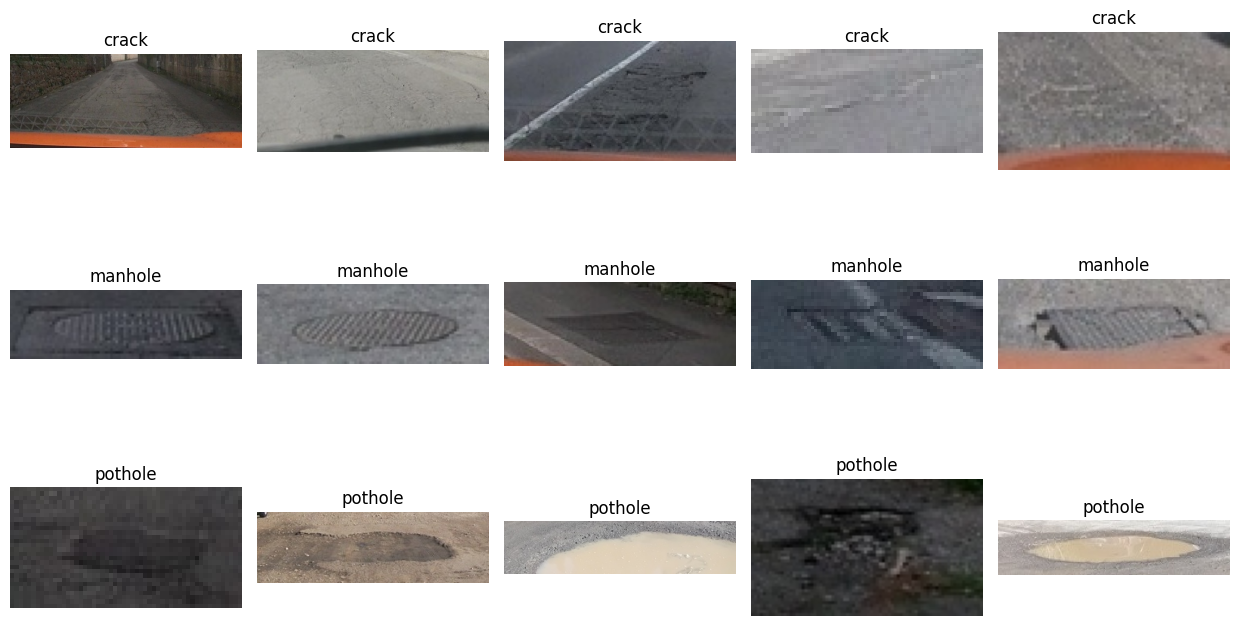

In [8]:
def show_samples(df, split="train", samples_per_class=5):
    class_names = sorted(df["class_name"].unique())
    plt.figure(figsize=(samples_per_class * 2.5, len(class_names) * 2.5))
    plot_index = 1

    for class_name in class_names:
        class_df = df[(df["split"] == split) & (df["class_name"] == class_name)]
        sample_paths = class_df["path"].sample(min(samples_per_class, len(class_df)), random_state=SEED)

        for image_path in sample_paths:
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            plt.subplot(len(class_names), samples_per_class, plot_index)
            plt.imshow(image)
            plt.title(class_name)
            plt.axis("off")
            plot_index += 1

    plt.tight_layout()
    plt.show()

show_samples(metadata_df)

## 8. Loading Dataset


In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "train",
    labels="inferred",
    label_mode="categorical",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "val",
    labels="inferred",
    label_mode="categorical",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "test",
    labels="inferred",
    label_mode="categorical",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Class names:", class_names)
print("Number of classes:", NUM_CLASSES)

Found 2322 files belonging to 3 classes.
Found 496 files belonging to 3 classes.
Found 510 files belonging to 3 classes.
Class names: ['crack', 'manhole', 'pothole']
Number of classes: 3


In [10]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First label:", labels[0].numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 3)
First label: [0. 1. 0.]


## 9. Compute Class Weights

In [11]:
train_labels = metadata_df[metadata_df["split"] == "train"]["class_name"].to_numpy()

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(class_names),
    y=train_labels,
)

class_weights = {index: float(weight) for index, weight in enumerate(weights)}
class_weights

{0: 0.4901836605446485, 1: 2.5714285714285716, 2: 1.751131221719457}

## 10. CNN Architecture 


In [12]:
def conv_block(x, filters, spatial_dropout):
    regularizer = tf.keras.regularizers.L2(1e-4)

    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False, kernel_regularizer=regularizer)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False, kernel_regularizer=regularizer)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)
    x = tf.keras.layers.SpatialDropout2D(spatial_dropout)(x)
    return x


inputs = tf.keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3), name="input_image")

x = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.04),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomContrast(0.15),
], name="data_augmentation")(inputs)

x = tf.keras.layers.Rescaling(1.0 / 255)(x)

x = conv_block(x, filters=32, spatial_dropout=0.05)
x = conv_block(x, filters=64, spatial_dropout=0.10)
x = conv_block(x, filters=128, spatial_dropout=0.15)
x = conv_block(x, filters=256, spatial_dropout=0.20)

x = tf.keras.layers.Conv2D(384, 3, padding="same", use_bias=False, kernel_regularizer=tf.keras.regularizers.L2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(384, use_bias=False, kernel_regularizer=tf.keras.regularizers.L2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = tf.keras.layers.Dropout(DROPOUT_RATE)(x)

outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="damage_class")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs, name="professional_custom_cnn")
model.summary()

Model: "professional_custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 224, 224, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 224, 224, 32)        │           9,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 224, 224, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout2d (SpatialDropout2D) │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 112, 112, 64)        │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 112, 112, 64)        │          36,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout2d_1                  │ (None, 56, 56, 64)          │               0 │
│ (SpatialDropout2D)                   │                             │              

 Total params: 2,211,555 (8.44 MB)

 Trainable params: 2,208,099 (8.42 MB)

 Non-trainable params: 3,456 (13.50 KB)

## 11. Compile Model

We use label smoothing to reduce overconfidence and improve generalization.

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc", multi_label=True),
    ],
)

## 12. Define Training Callbacks

In [14]:
checkpoint_path = MODEL_DIR / "road_damage_self_contained_cnn.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

## 13. Train Model

In [15]:
start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
)

training_time_minutes = (time.time() - start_time) / 60
print(f"Training time: {training_time_minutes:.2f} minutes")

Epoch 1/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3626 - auc: 0.5196 - loss: 1.6631 - precision: 0.4020 - recall: 0.2691
Epoch 1: val_accuracy improved from -inf to 0.14919, saving model to ml\models\road_damage_self_contained_cnn.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 291s 4s/step - accuracy: 0.3627 - auc: 0.5199 - loss: 1.6609 - precision: 0.4023 - recall: 0.2685 - val_accuracy: 0.1492 - val_auc: 0.4899 - val_loss: 1.3659 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3779 - auc: 0.5917 - loss: 1.3195 - precision: 0.4817 - recall: 0.1545
Epoch 2: val_accuracy did not improve from 0.14919
73/73 ━━━━━━━━━━━━━━━━━━━━ 297s 4s/step - accuracy: 0.3779 - auc: 0.5916 - loss: 1.3198 - precision: 0.4817 - recall: 0.1547 - val_accuracy: 0.1452 - val_auc: 0.4767 - val_loss: 1.5035 - val_precision: 0.0417 - val_recall: 0.0020 - learning_rate: 0.0010
Epoch 3/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step 

## 14. Plot Training Curves

In [16]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(REPORT_DIR / "road_damage_self_contained_cnn_history.csv", index=False)
history_df.tail()

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
12,0.468992,0.671208,1.195405,0.632075,0.259690,0.336694,0.606478,1.315743,0.417969,0.215726,0.000300
13,0.470284,0.689792,1.165904,0.613967,0.272610,0.328629,0.616939,1.299572,0.402655,0.183468,0.000090
14,0.512489,0.707351,1.150676,0.656057,0.319552,0.491935,0.680839,1.165447,0.576190,0.243952,0.000090
15,0.487941,0.698416,1.157706,0.616041,0.310939,0.502016,0.683944,1.154820,0.587156,0.258065,0.000090
16,0.511197,0.715556,1.135781,0.649957,0.323859,0.510081,0.686514,1.152005,0.660194,0.274194,0.000027


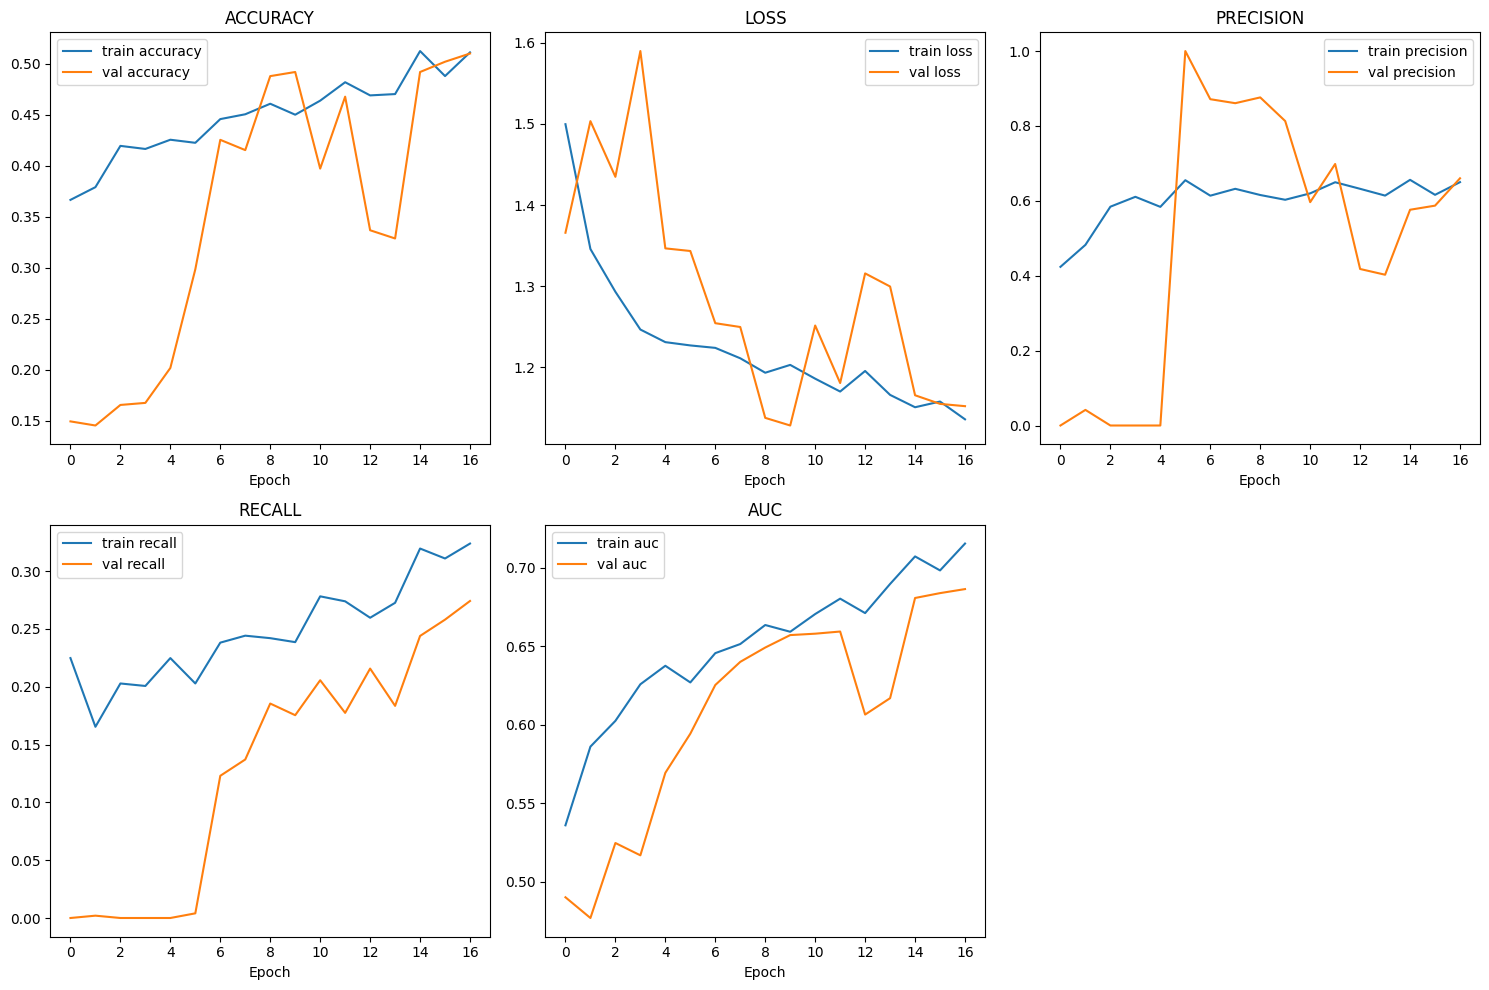

In [17]:
metrics_to_plot = ["accuracy", "loss", "precision", "recall", "auc"]

plt.figure(figsize=(15, 10))
for index, metric in enumerate(metrics_to_plot, start=1):
    plt.subplot(2, 3, index)
    plt.plot(history_df[metric], label=f"train {metric}")
    plt.plot(history_df[f"val_{metric}"], label=f"val {metric}")
    plt.title(metric.upper())
    plt.xlabel("Epoch")
    plt.legend()

plt.tight_layout()
plt.show()

## 15. Evaluate with Keras

In [18]:
keras_test_results = model.evaluate(test_ds, verbose=1)
dict(zip(model.metrics_names, keras_test_results))

16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 623ms/step - accuracy: 0.5516 - auc: 0.2251 - loss: 1.0669 - precision: 0.9448 - recall: 0.2238


{'loss': 1.1033018827438354, 'compile_metrics': 0.5156862735748291}

## 16. Evaluate with sklearn Metrics

In [19]:
y_true = []
y_prob = []

for image_batch, label_batch in test_ds:
    probabilities = model.predict(image_batch, verbose=0)
    y_prob.append(probabilities)
    y_true.extend(np.argmax(label_batch.numpy(), axis=1))

y_prob = np.vstack(y_prob)
y_true = np.array(y_true)
y_pred = np.argmax(y_prob, axis=1)

summary_metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
    "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
}

try:
    y_true_binary = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
    summary_metrics["roc_auc_ovr_macro"] = roc_auc_score(y_true_binary, y_prob, average="macro", multi_class="ovr")
except ValueError as error:
    summary_metrics["roc_auc_ovr_macro"] = None
    print("AUC skipped:", error)

summary_metrics

{'accuracy': 0.515686274509804,
 'precision_macro': 0.4248533156983861,
 'recall_macro': 0.45034409441098733,
 'f1_macro': 0.40628457070401197,
 'precision_weighted': 0.6396492350510578,
 'recall_weighted': 0.515686274509804,
 'f1_weighted': 0.5465229852797234,
 'roc_auc_ovr_macro': 0.6563373827346892}

In [20]:
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

       crack       0.83      0.55      0.66       347
     manhole       0.15      0.16      0.16        69
     pothole       0.29      0.64      0.40        94

    accuracy                           0.52       510
   macro avg       0.42      0.45      0.41       510
weighted avg       0.64      0.52      0.55       510



## 17. Confusion Matrix

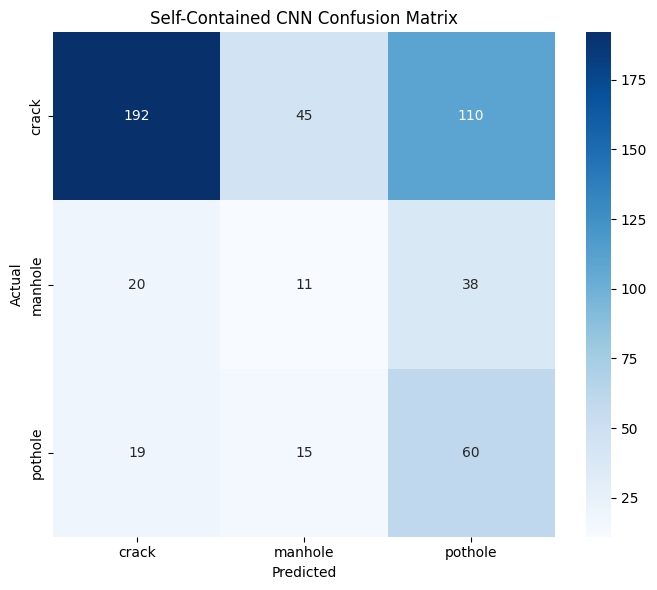

In [21]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Self-Contained CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 18. Save Model, Labels, and Metrics

In [22]:
model.save(MODEL_DIR / "road_damage_self_contained_cnn.keras")
(MODEL_DIR / "road_damage_self_contained_cnn_labels.json").write_text(json.dumps(class_names, indent=2), encoding="utf-8")
(REPORT_DIR / "road_damage_self_contained_cnn_metrics.json").write_text(json.dumps(summary_metrics, indent=2), encoding="utf-8")

print("Saved model:", MODEL_DIR / "road_damage_self_contained_cnn.keras")
print("Saved labels:", MODEL_DIR / "road_damage_self_contained_cnn_labels.json")
print("Saved metrics:", REPORT_DIR / "road_damage_self_contained_cnn_metrics.json")

Saved model: ml\models\road_damage_self_contained_cnn.keras
Saved labels: ml\models\road_damage_self_contained_cnn_labels.json
Saved metrics: ml\reports\road_damage_self_contained_cnn_metrics.json
